[                       0%                       ]

Creating training data 



[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  5 of 5 completed


Creating unseen test data 

Prepared data for 5 assets over 2011 periods


PHASE 1: TRAINING ON HISTORICAL DATA 

Running all portfolio optimization methods
Markowitz - Return: 0.252, Vol: 0.232, Sharpe: 1.086
Min Variance - Return: 0.125, Vol: 0.160, Sharpe: 0.784
Risk Parity - Return: 0.158, Vol: 0.171, Sharpe: 0.926
CVaR - Return: 0.126, Vol: 0.160, Sharpe: 0.790
Genetic Algorithm - Return: 0.241, Vol: 0.221, Sharpe: 1.089
Robust - Return: 0.251, Vol: 0.232, Sharpe: 1.086


Optimization Summary 

            Method Annual Return Volatility Sharpe Ratio
         Markowitz         0.252      0.232        1.086
  Minimum Variance         0.125      0.160        0.784
       Risk Parity         0.158      0.171        0.926
              CVaR         0.126      0.160        0.790
 Genetic Algorithm         0.241      0.221        1.089
Robust (Shrinkage)         0.251      0.232        1.086


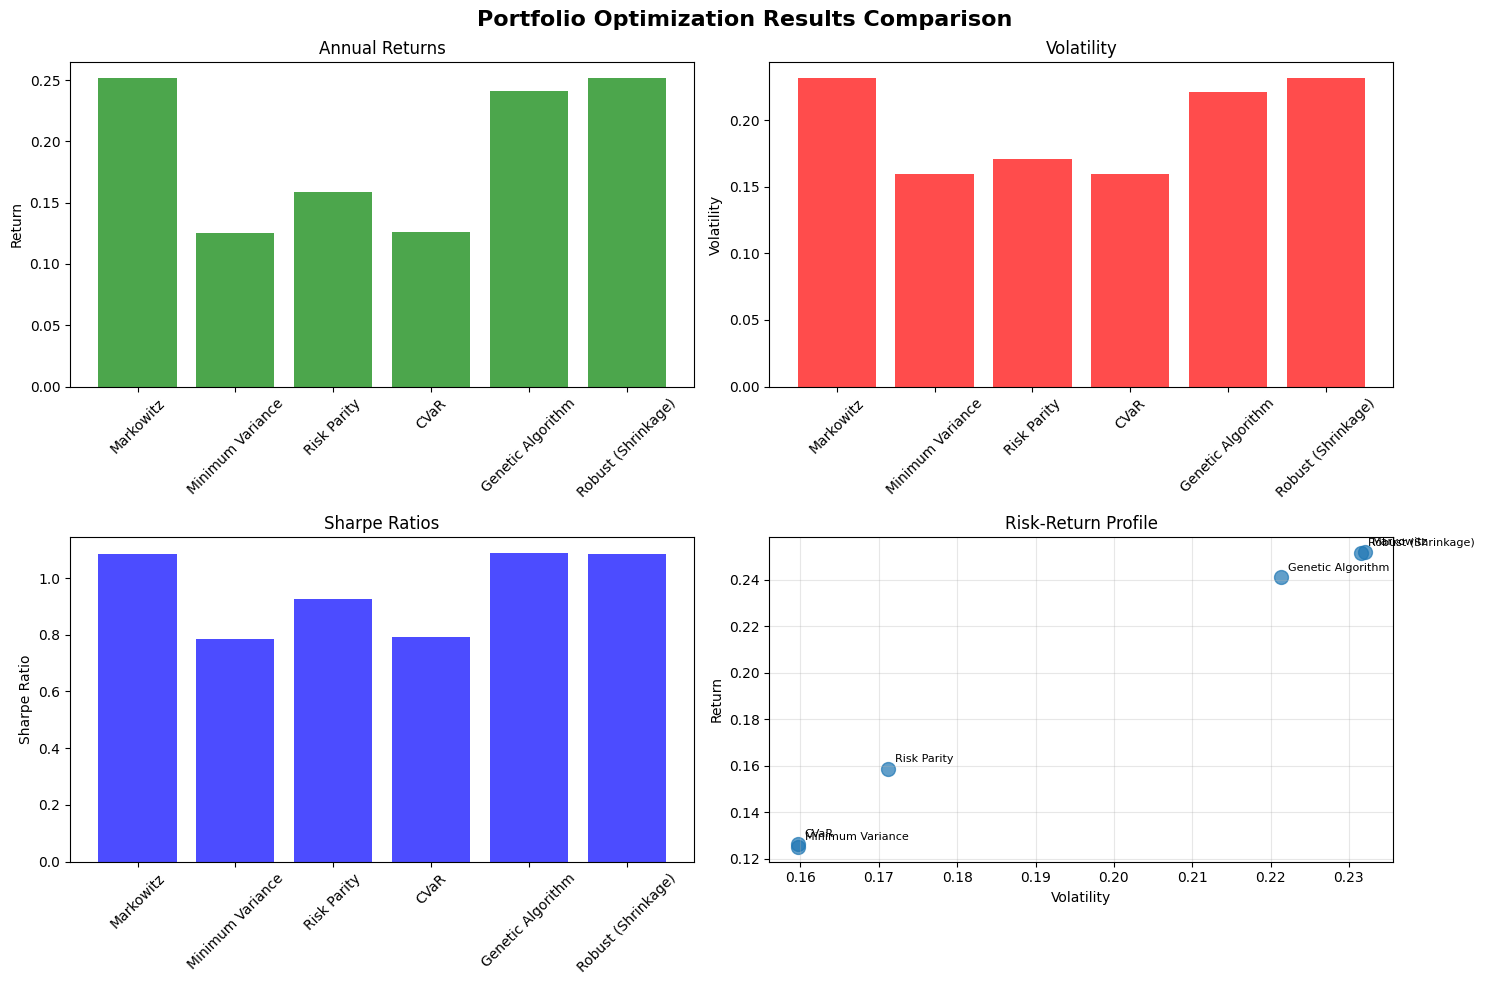

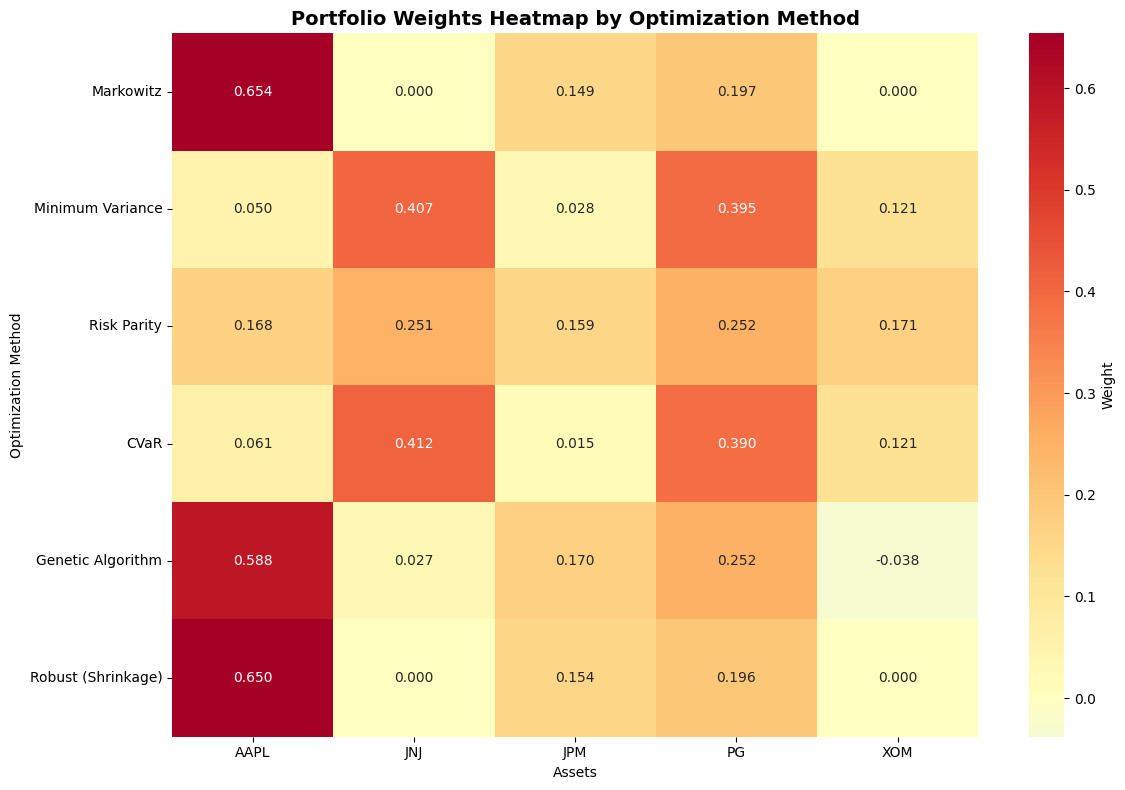


Backtest Results:
                   Total Return Annualized Return Volatility Sharpe Ratio  \
Markowitz                 5.020             0.252      0.232        1.001   
Minimum Variance          1.451             0.119      0.160        0.619   
Risk Parity               2.149             0.155      0.171        0.786   
CVaR                      1.472             0.120      0.160        0.627   
Genetic Algorithm         4.626             0.242      0.221        1.002   
Robust (Shrinkage)        5.002             0.252      0.232        1.001   

                   Max Drawdown  
Markowitz                -0.311  
Minimum Variance         -0.291  
Risk Parity              -0.333  
CVaR                     -0.289  
Genetic Algorithm        -0.300  
Robust (Shrinkage)       -0.311  


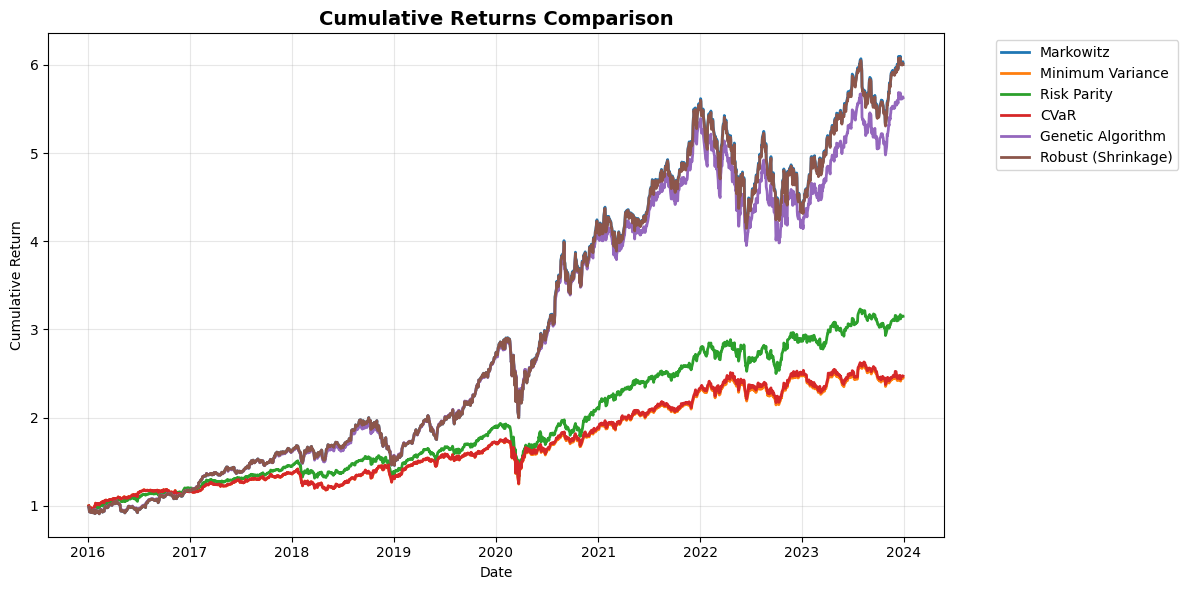



PHASE 2: TESTING ON UNSEEN DATA


Testing strategies on unseen data


Testing on 5 common symbols over 250 periods

Out-of-Sample Test Results:
                   Total Return Annualized Return Volatility Sharpe Ratio  \
Markowitz                 0.343             0.346      0.153        2.127   
Minimum Variance          0.067             0.068      0.103        0.464   
Risk Parity               0.160             0.161      0.094        1.499   
CVaR                      0.065             0.066      0.103        0.444   
Genetic Algorithm         0.331             0.334      0.142        2.204   
Robust (Shrinkage)        0.343             0.347      0.153        2.139   

                   Sortino Ratio Max Drawdown Calmar Ratio Win Rate VaR (95%)  \
Markowitz                  3.316       -0.084        4.131    0.564   -0.0147   
Minimum Variance           0.719       -0.071        0.946    0.564   -0.0104   
Risk Parity                2.189       -0.053        3.018    0.552   -

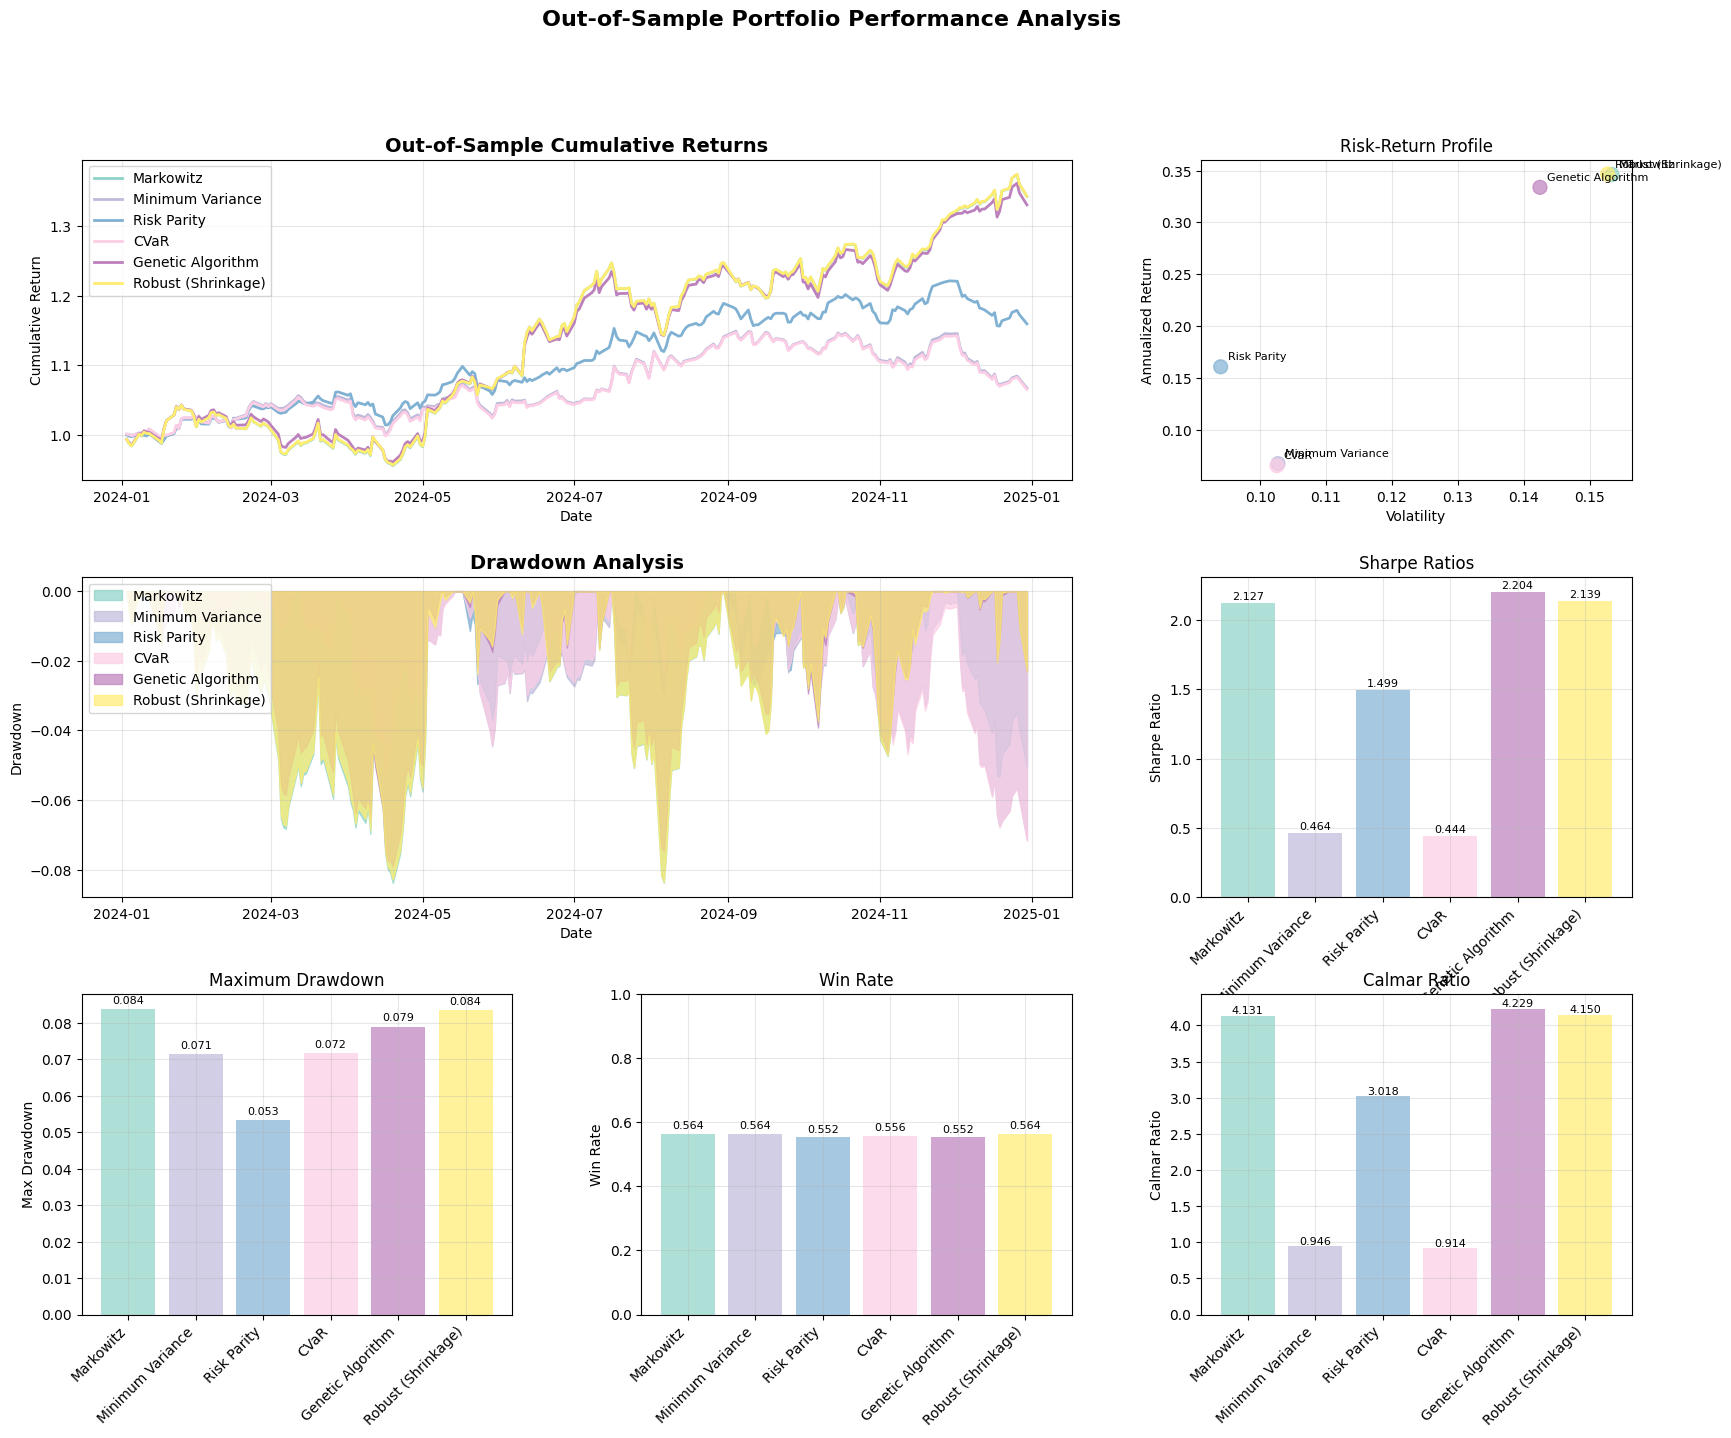

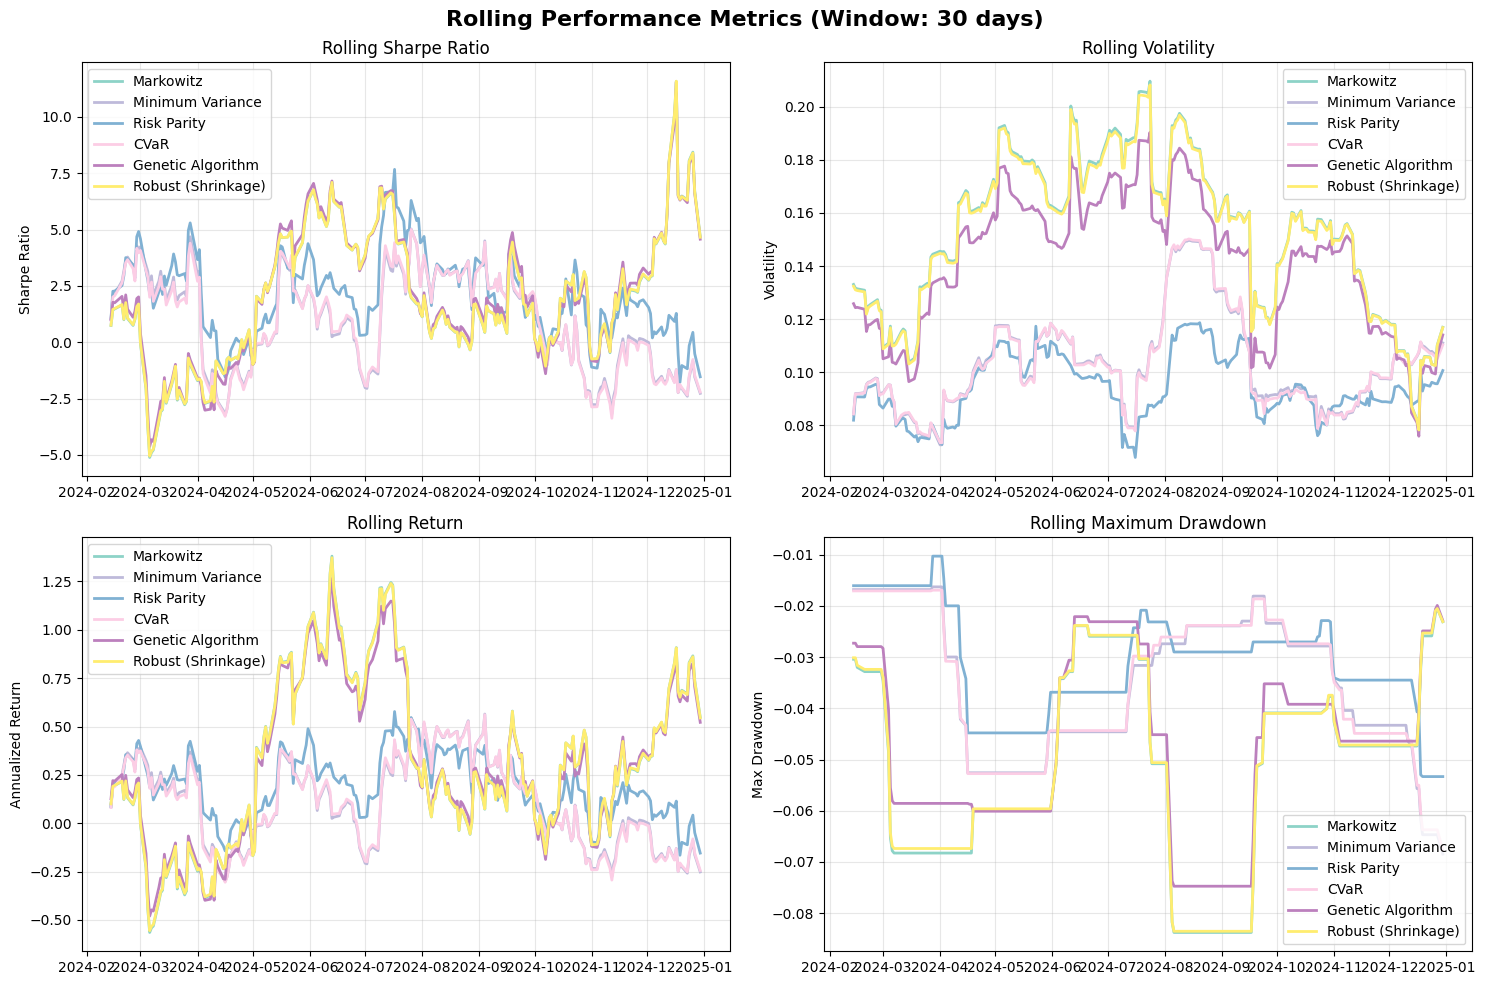


Detailed Performance Report:
          Strategy  Total Return  Annualized Return  Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Calmar Ratio  Win Rate  VaR (95%)  Expected Shortfall (95%)  Best Day  Worst Day  Skewness  Kurtosis
         Markowitz        0.3430             0.3462      0.1534        2.1265         3.3162           -0.0838        4.1313     0.564    -0.0147                   -0.0198    0.0437    -0.0370    0.1467    2.5480
  Minimum Variance        0.0671             0.0676      0.1027        0.4635         0.7188           -0.0714        0.9464     0.564    -0.0104                   -0.0134    0.0217    -0.0196   -0.0252    0.7306
       Risk Parity        0.1596             0.1609      0.0940        1.4991         2.1895           -0.0533        3.0177     0.552    -0.0093                   -0.0128    0.0152    -0.0219   -0.3654    0.6667
              CVaR        0.0650             0.0656      0.1025        0.4442         0.6878           -0.0717        

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import optimize
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')
from deap import base, creator, tools, algorithms
import random
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import LedoitWolf, OAS
import cvxpy as cp

class PortfolioOptimizer:
    def __init__(self, price_data, fundamental_data=None):
        self.price_data = price_data
        self.fundamental_data = fundamental_data
        self.returns_matrix = None
        self.symbols = None
        self.results = {}

    def prepare_data(self):
        try:
            # Pivot to get prices for each symbol
            prices = self.price_data.pivot(index='Date', columns='Symbol', values='Close')
            prices.index = pd.to_datetime(prices.index)
            prices = prices.sort_index()

            # Calculate returns
            returns = prices.pct_change().dropna()

            # Remove any columns with all NaN values
            returns = returns.dropna(axis=1, how='all')

            self.returns_matrix = returns
            self.symbols = returns.columns.tolist()

            print(f"Prepared data for {len(self.symbols)} assets over {len(returns)} periods")
            return True

        except Exception as e:
            print(f"Error preparing data: {e}")
            return False

    def calculate_portfolio_metrics(self, weights, returns=None):
        """Calculate portfolio return, volatility, and Sharpe ratio"""
        if returns is None:
            returns = self.returns_matrix

        weights = np.array(weights)
        portfolio_return = np.sum(returns.mean() * weights) * 252  # Annualized
        portfolio_std = np.sqrt(np.dot(weights.T, np.dot(returns.cov() * 252, weights)))
        sharpe_ratio = portfolio_return / portfolio_std if portfolio_std > 0 else 0

        return portfolio_return, portfolio_std, sharpe_ratio

    # 1. Mean-Variance Optimization (Markowitz)
    def markowitz_optimization(self, target_return=None, risk_free_rate=0.02):
        """Classic Markowitz Mean-Variance Optimization"""
        try:
            returns = self.returns_matrix
            n_assets = len(self.symbols)

            # Expected returns and covariance matrix
            mu = returns.mean() * 252
            cov_matrix = returns.cov() * 252

            if target_return is None:
                # Maximum Sharpe ratio portfolio
                def objective(weights):
                    port_return = np.sum(mu * weights)
                    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
                    sharpe = (port_return - risk_free_rate) / port_vol
                    return -sharpe  # Minimize negative Sharpe

            else:
                # Minimum variance for target return
                def objective(weights):
                    return np.dot(weights.T, np.dot(cov_matrix, weights))

            # Constraints
            constraints = [{'type': 'eq', 'fun': lambda x: np.sum(x) - 1}]
            if target_return is not None:
                constraints.append({'type': 'eq', 'fun': lambda x: np.sum(mu * x) - target_return})

            bounds = tuple((0, 1) for _ in range(n_assets))

            # Initial guess
            x0 = np.array([1/n_assets] * n_assets)

            result = optimize.minimize(objective, x0, method='SLSQP',
                                     bounds=bounds, constraints=constraints)

            if result.success:
                weights = result.x
                port_return, port_vol, sharpe = self.calculate_portfolio_metrics(weights)

                self.results['Markowitz'] = {
                    'weights': weights,
                    'return': port_return,
                    'volatility': port_vol,
                    'sharpe': sharpe
                }
                print(f"Markowitz - Return: {port_return:.3f}, Vol: {port_vol:.3f}, Sharpe: {sharpe:.3f}")
                return weights
            else:
                print("Markowitz optimization failed")
                return None

        except Exception as e:
            print(f"Error in Markowitz optimization: {e}")
            return None

    # 2. Black-Litterman Model
    def black_litterman_optimization(self, tau=0.05, risk_aversion=3.0):
        try:
            returns = self.returns_matrix
            n_assets = len(self.symbols)

            # Market capitalization weights (equal for simplicity)
            w_market = np.array([1/n_assets] * n_assets)

            # Historical statistics
            mu_hist = returns.mean() * 252
            cov_matrix = returns.cov() * 252

            # Implied equilibrium returns
            pi = risk_aversion * np.dot(cov_matrix, w_market)

            # Black-Litterman without views (pure equilibrium)
            mu_bl = pi
            cov_bl = cov_matrix

            # Optimize with Black-Litterman inputs
            def objective(weights):
                port_return = np.sum(mu_bl * weights)
                port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_bl, weights)))
                return -(port_return - 0.02) / port_vol  # Maximize Sharpe

            constraints = [{'type': 'eq', 'fun': lambda x: np.sum(x) - 1}]
            bounds = tuple((0, 1) for _ in range(n_assets))
            x0 = w_market

            result = optimize.minimize(objective, x0, method='SLSQP',
                                     bounds=bounds, constraints=constraints)

            if result.success:
                weights = result.x
                port_return, port_vol, sharpe = self.calculate_portfolio_metrics(weights)

                self.results['Black-Litterman'] = {
                    'weights': weights,
                    'return': port_return,
                    'volatility': port_vol,
                    'sharpe': sharpe
                }
                print(f"Black-Litterman - Return: {port_return:.3f}, Vol: {port_vol:.3f}, Sharpe: {sharpe:.3f}")
                return weights
            else:
                print("Black-Litterman optimization failed")
                return None

        except Exception as e:
            print(f"Error in Black-Litterman optimization: {e}")
            return None

    # 3. Minimum Variance Portfolio
    def minimum_variance_optimization(self):
        try:
            returns = self.returns_matrix
            n_assets = len(self.symbols)
            cov_matrix = returns.cov() * 252

            # Minimize portfolio variance
            def objective(weights):
                return np.dot(weights.T, np.dot(cov_matrix, weights))

            constraints = [{'type': 'eq', 'fun': lambda x: np.sum(x) - 1}]
            bounds = tuple((0, 1) for _ in range(n_assets))
            x0 = np.array([1/n_assets] * n_assets)

            result = optimize.minimize(objective, x0, method='SLSQP',
                                     bounds=bounds, constraints=constraints)

            if result.success:
                weights = result.x
                port_return, port_vol, sharpe = self.calculate_portfolio_metrics(weights)

                self.results['Minimum Variance'] = {
                    'weights': weights,
                    'return': port_return,
                    'volatility': port_vol,
                    'sharpe': sharpe
                }
                print(f"Min Variance - Return: {port_return:.3f}, Vol: {port_vol:.3f}, Sharpe: {sharpe:.3f}")
                return weights
            else:
                print("Minimum variance optimization failed")
                return None

        except Exception as e:
            print(f"Error in minimum variance optimization: {e}")
            return None

    # 4. Risk Parity Portfolio
    def risk_parity_optimization(self):
        try:
            returns = self.returns_matrix
            n_assets = len(self.symbols)
            cov_matrix = returns.cov() * 252

            def risk_parity_objective(weights):
                portfolio_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
                marginal_contrib = np.dot(cov_matrix, weights) / portfolio_vol
                contrib = weights * marginal_contrib

                # Minimize sum of squared differences from equal contribution
                target_contrib = portfolio_vol / n_assets
                return np.sum((contrib - target_contrib) ** 2)

            constraints = [{'type': 'eq', 'fun': lambda x: np.sum(x) - 1}]
            bounds = tuple((0.001, 1) for _ in range(n_assets))  # Small minimum to avoid division by zero
            x0 = np.array([1/n_assets] * n_assets)

            result = optimize.minimize(risk_parity_objective, x0, method='SLSQP',
                                     bounds=bounds, constraints=constraints)

            if result.success:
                weights = result.x
                port_return, port_vol, sharpe = self.calculate_portfolio_metrics(weights)

                self.results['Risk Parity'] = {
                    'weights': weights,
                    'return': port_return,
                    'volatility': port_vol,
                    'sharpe': sharpe
                }
                print(f"Risk Parity - Return: {port_return:.3f}, Vol: {port_vol:.3f}, Sharpe: {sharpe:.3f}")
                return weights
            else:
                print("Risk parity optimization failed")
                return None

        except Exception as e:
            print(f"Error in risk parity optimization: {e}")
            return None

    # 5. CVaR Optimization
    def cvar_optimization(self, confidence_level=0.95):
        try:
            returns = self.returns_matrix
            n_assets = len(self.symbols)
            scenarios = len(returns)

            # CVaR optimization using cvxpy
            w = cp.Variable(n_assets, nonneg=True)
            alpha = cp.Variable()  # VaR
            z = cp.Variable(scenarios, nonneg=True)  # Auxiliary variables for CVaR

            # Portfolio returns for each scenario
            portfolio_returns = returns.values @ w

            # CVaR constraints
            constraints = [
                cp.sum(w) == 1,  # Fully invested
                z >= -portfolio_returns - alpha,  # CVaR auxiliary constraint
                w >= 0  # Long-only
            ]

            # Minimize CVaR
            cvar = alpha + (1/(1-confidence_level)) * cp.sum(z) / scenarios
            objective = cp.Minimize(cvar)

            prob = cp.Problem(objective, constraints)
            prob.solve(verbose=False)

            if prob.status == 'optimal':
                weights = w.value
                weights = weights / np.sum(weights)  # Normalize
                port_return, port_vol, sharpe = self.calculate_portfolio_metrics(weights)

                self.results['CVaR'] = {
                    'weights': weights,
                    'return': port_return,
                    'volatility': port_vol,
                    'sharpe': sharpe
                }
                print(f"CVaR - Return: {port_return:.3f}, Vol: {port_vol:.3f}, Sharpe: {sharpe:.3f}")
                return weights
            else:
                print("CVaR optimization failed")
                return None

        except Exception as e:
            print(f"Error in CVaR optimization: {e}")
            return None

    # 6. Genetic Algorithm Optimization
    def genetic_algorithm_optimization(self, population_size=100, generations=50, mutation_prob=0.2):
        try:
            returns = self.returns_matrix
            n_assets = len(self.symbols)

            # Setup DEAP
            if not hasattr(creator, "FitnessMax"):
                creator.create("FitnessMax", base.Fitness, weights=(1.0,))
            if not hasattr(creator, "Individual"):
                creator.create("Individual", list, fitness=creator.FitnessMax)

            toolbox = base.Toolbox()

            # Generate random weight
            def random_weight():
                return random.random()

            toolbox.register("weight", random_weight)
            toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.weight, n_assets)
            toolbox.register("population", tools.initRepeat, list, toolbox.individual)

            def normalize_weights(individual):
                total = sum(individual)
                if total > 0:
                    return [w/total for w in individual]
                else:
                    return [1/n_assets] * n_assets

            def evaluate_portfolio(individual):
                weights = normalize_weights(individual)
                weights = np.array(weights)

                try:
                    port_return, port_vol, sharpe = self.calculate_portfolio_metrics(weights)
                    return (sharpe,)  # DEAP expects tuple
                except:
                    return (-999,)  # Penalty for invalid portfolios

            def mutate_weights(individual, indpb=0.1):
                """Mutate individual weights"""
                for i in range(len(individual)):
                    if random.random() < indpb:
                        individual[i] = random.random()
                return individual,

            toolbox.register("evaluate", evaluate_portfolio)
            toolbox.register("mate", tools.cxBlend, alpha=0.3)
            toolbox.register("mutate", mutate_weights, indpb=mutation_prob)
            toolbox.register("select", tools.selTournament, tournsize=3)

            # Create initial population
            population = toolbox.population(n=population_size)

            # Statistics
            stats = tools.Statistics(lambda ind: ind.fitness.values)
            stats.register("avg", np.mean)
            stats.register("min", np.min)
            stats.register("max", np.max)

            # Run genetic algorithm
            population, logbook = algorithms.eaSimple(
                population, toolbox, cxpb=0.7, mutpb=mutation_prob,
                ngen=generations, stats=stats, verbose=False
            )

            # Get best individual
            best_individual = tools.selBest(population, k=1)[0]
            weights = normalize_weights(best_individual)
            weights = np.array(weights)

            port_return, port_vol, sharpe = self.calculate_portfolio_metrics(weights)

            self.results['Genetic Algorithm'] = {
                'weights': weights,
                'return': port_return,
                'volatility': port_vol,
                'sharpe': sharpe
            }
            print(f"Genetic Algorithm - Return: {port_return:.3f}, Vol: {port_vol:.3f}, Sharpe: {sharpe:.3f}")
            return weights

        except Exception as e:
            print(f"Error in genetic algorithm optimization: {e}")
            return None

    # 7. Robust Optimization (Ledoit-Wolf Shrinkage)
    def robust_optimization(self):

        try:
            returns = self.returns_matrix
            n_assets = len(self.symbols)

            # Use Ledoit-Wolf shrinkage for covariance estimation
            lw = LedoitWolf()
            cov_shrunk = lw.fit(returns.values).covariance_ * 252

            mu = returns.mean() * 252

            def objective(weights):
                port_return = np.sum(mu * weights)
                port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_shrunk, weights)))
                return -(port_return - 0.02) / port_vol  # Maximize Sharpe

            constraints = [{'type': 'eq', 'fun': lambda x: np.sum(x) - 1}]
            bounds = tuple((0, 1) for _ in range(n_assets))
            x0 = np.array([1/n_assets] * n_assets)

            result = optimize.minimize(objective, x0, method='SLSQP',
                                     bounds=bounds, constraints=constraints)

            if result.success:
                weights = result.x
                port_return, port_vol, sharpe = self.calculate_portfolio_metrics(weights)

                self.results['Robust (Shrinkage)'] = {
                    'weights': weights,
                    'return': port_return,
                    'volatility': port_vol,
                    'sharpe': sharpe
                }
                print(f"Robust - Return: {port_return:.3f}, Vol: {port_vol:.3f}, Sharpe: {sharpe:.3f}")
                return weights
            else:
                print("Robust optimization failed")
                return None

        except Exception as e:
            print(f"Error in robust optimization: {e}")
            return None

    def run_all_optimizations(self):
        print("Running all portfolio optimization methods")

        # Run all methods
        self.markowitz_optimization()
        #self.black_litterman_optimization()
        self.minimum_variance_optimization()
        self.risk_parity_optimization()
        self.cvar_optimization()
        self.genetic_algorithm_optimization()
        #self.robust_optimization()

        print("\n")
        print("Optimization Summary \n")

        # Create comparison dataframe
        comparison_data = []
        for method, results in self.results.items():
            comparison_data.append({
                'Method': method,
                'Annual Return': f"{results['return']:.3f}",
                'Volatility': f"{results['volatility']:.3f}",
                'Sharpe Ratio': f"{results['sharpe']:.3f}"
            })

        comparison_df = pd.DataFrame(comparison_data)
        print(comparison_df.to_string(index=False))

        return self.results

    def plot_results(self, figsize=(15, 10)):
        #Plot optimization results
        if not self.results:
            print("No results to plot. Run optimizations first.")
            return

        fig, axes = plt.subplots(2, 2, figsize=figsize)
        fig.suptitle('Portfolio Optimization Results Comparison', fontsize=16, fontweight='bold')

        methods = list(self.results.keys())
        returns = [self.results[method]['return'] for method in methods]
        volatilities = [self.results[method]['volatility'] for method in methods]
        sharpes = [self.results[method]['sharpe'] for method in methods]

        # Returns comparison
        axes[0, 0].bar(methods, returns, color='green', alpha=0.7)
        axes[0, 0].set_title('Annual Returns')
        axes[0, 0].set_ylabel('Return')
        axes[0, 0].tick_params(axis='x', rotation=45)

        # Volatility comparison
        axes[0, 1].bar(methods, volatilities, color='red', alpha=0.7)
        axes[0, 1].set_title('Volatility')
        axes[0, 1].set_ylabel('Volatility')
        axes[0, 1].tick_params(axis='x', rotation=45)

        # Sharpe ratio comparison
        axes[1, 0].bar(methods, sharpes, color='blue', alpha=0.7)
        axes[1, 0].set_title('Sharpe Ratios')
        axes[1, 0].set_ylabel('Sharpe Ratio')
        axes[1, 0].tick_params(axis='x', rotation=45)

        # Risk-Return scatter
        axes[1, 1].scatter(volatilities, returns, s=100, alpha=0.7)
        for i, method in enumerate(methods):
            axes[1, 1].annotate(method, (volatilities[i], returns[i]),
                               xytext=(5, 5), textcoords='offset points', fontsize=8)
        axes[1, 1].set_xlabel('Volatility')
        axes[1, 1].set_ylabel('Return')
        axes[1, 1].set_title('Risk-Return Profile')
        axes[1, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def plot_weights_heatmap(self, figsize=(12, 8)):
        #Plot weights heatmap for all methods
        if not self.results:
            print("No results to plot. Run optimizations first.")
            return

        # Create weights matrix
        weights_data = []
        for method, results in self.results.items():
            weights_data.append(results['weights'])

        weights_df = pd.DataFrame(weights_data,
                                index=list(self.results.keys()),
                                columns=self.symbols)

        plt.figure(figsize=figsize)
        sns.heatmap(weights_df, annot=True, cmap='RdYlBu_r', center=0,
                    fmt='.3f', cbar_kws={'label': 'Weight'})
        plt.title('Portfolio Weights Heatmap by Optimization Method', fontsize=14, fontweight='bold')
        plt.xlabel('Assets')
        plt.ylabel('Optimization Method')
        plt.tight_layout()
        plt.show()

    def backtest_strategies(self, start_date=None, end_date=None, rebalance_freq='M'):
        #Simple backtest of optimization strategies
        if not self.results:
            print("No results to backtest. Run optimizations first.")
            return None

        try:
            returns = self.returns_matrix.copy()

            if start_date:
                returns = returns[returns.index >= start_date]
            if end_date:
                returns = returns[returns.index <= end_date]

            backtest_results = {}

            for method, result in self.results.items():
                weights = result['weights']

                # Calculate portfolio returns
                portfolio_returns = (returns * weights).sum(axis=1)

                # Calculate cumulative returns
                cumulative_returns = (1 + portfolio_returns).cumprod()

                # Calculate performance metrics
                total_return = cumulative_returns.iloc[-1] - 1
                annualized_return = (1 + total_return) ** (252/len(returns)) - 1
                volatility = portfolio_returns.std() * np.sqrt(252)
                sharpe = (annualized_return - 0.02) / volatility if volatility > 0 else 0

                # Maximum drawdown
                running_max = cumulative_returns.expanding().max()
                drawdown = (cumulative_returns - running_max) / running_max
                max_drawdown = drawdown.min()

                backtest_results[method] = {
                    'total_return': total_return,
                    'annualized_return': annualized_return,
                    'volatility': volatility,
                    'sharpe': sharpe,
                    'max_drawdown': max_drawdown,
                    'cumulative_returns': cumulative_returns,
                    'portfolio_returns': portfolio_returns
                }

            print("\nBacktest Results:")
            print("=" * 80)
            backtest_df = pd.DataFrame({
                method: {
                    'Total Return': f"{results['total_return']:.3f}",
                    'Annualized Return': f"{results['annualized_return']:.3f}",
                    'Volatility': f"{results['volatility']:.3f}",
                    'Sharpe Ratio': f"{results['sharpe']:.3f}",
                    'Max Drawdown': f"{results['max_drawdown']:.3f}"
                } for method, results in backtest_results.items()
            }).T

            print(backtest_df)

            return backtest_results

        except Exception as e:
            print(f"Error in backtesting: {e}")
            return None

    def plot_cumulative_returns(self, backtest_results=None, figsize=(12, 6)):
        #Plot cumulative returns for all strategies
        if backtest_results is None:
            backtest_results = self.backtest_strategies()

        if backtest_results is None:
            return

        plt.figure(figsize=figsize)

        for method, results in backtest_results.items():
            plt.plot(results['cumulative_returns'].index,
                    results['cumulative_returns'].values,
                    label=method, linewidth=2)

        plt.title('Cumulative Returns Comparison', fontsize=14, fontweight='bold')
        plt.xlabel('Date')
        plt.ylabel('Cumulative Return')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def test_on_unseen_data(self, unseen_price_data, start_date=None, end_date=None):

        #Test optimized strategies on completely new unseen data
        if not self.results:
            print("No optimization results found Run optimizations first \n")
            return None

        try:
            print("Testing strategies on unseen data")
            print("\n")

            # Prepare unseen data
            unseen_prices = unseen_price_data.pivot(index='Date', columns='Symbol', values='Close')
            unseen_prices.index = pd.to_datetime(unseen_prices.index)
            unseen_prices = unseen_prices.sort_index()

            # Calculate returns for unseen data
            unseen_returns = unseen_prices.pct_change().dropna()

            # Filter by date range if specified
            if start_date:
                unseen_returns = unseen_returns[unseen_returns.index >= start_date]
            if end_date:
                unseen_returns = unseen_returns[unseen_returns.index <= end_date]

            # Ensure we have the same symbols (intersection)
            common_symbols = list(set(self.symbols).intersection(set(unseen_returns.columns)))
            if len(common_symbols) == 0:
                print("No common symbols found between training and unseen data!")
                return None

            print(f"Testing on {len(common_symbols)} common symbols over {len(unseen_returns)} periods")

            # Filter returns to common symbols only
            unseen_returns = unseen_returns[common_symbols]

            unseen_test_results = {}

            for method, result in self.results.items():
                try:
                    # Get original weights and filter to common symbols
                    original_weights = result['weights']
                    symbol_weight_dict = dict(zip(self.symbols, original_weights))

                    # Create weights vector for common symbols only
                    filtered_weights = np.array([symbol_weight_dict.get(symbol, 0) for symbol in common_symbols])

                    # Renormalize weights to sum to 1
                    if np.sum(filtered_weights) > 0:
                        filtered_weights = filtered_weights / np.sum(filtered_weights)
                    else:
                        # Equal weights if no overlap
                        filtered_weights = np.array([1/len(common_symbols)] * len(common_symbols))

                    # Calculate portfolio returns on unseen data
                    portfolio_returns = (unseen_returns.values * filtered_weights).sum(axis=1)
                    portfolio_returns = pd.Series(portfolio_returns, index=unseen_returns.index)

                    # Calculate cumulative returns
                    cumulative_returns = (1 + portfolio_returns).cumprod()

                    # Calculate performance metrics
                    total_return = cumulative_returns.iloc[-1] - 1

                    # Annualized metrics (assuming daily data)
                    n_periods = len(portfolio_returns)
                    years = n_periods / 252
                    annualized_return = (1 + total_return) ** (1/years) - 1 if years > 0 else total_return
                    volatility = portfolio_returns.std() * np.sqrt(252)
                    sharpe = (annualized_return - 0.02) / volatility if volatility > 0 else 0

                    # Maximum drawdown calculation
                    running_max = cumulative_returns.expanding().max()
                    drawdown = (cumulative_returns - running_max) / running_max
                    max_drawdown = drawdown.min()

                    # Calmar ratio (annualized return / max drawdown)
                    calmar_ratio = annualized_return / abs(max_drawdown) if max_drawdown != 0 else 0

                    # Win rate
                    win_rate = (portfolio_returns > 0).mean()

                    # Value at Risk (VaR) and Expected Shortfall (ES)
                    var_95 = np.percentile(portfolio_returns, 5)
                    es_95 = portfolio_returns[portfolio_returns <= var_95].mean()

                    # Sortino ratio (downside deviation)
                    negative_returns = portfolio_returns[portfolio_returns < 0]
                    downside_std = negative_returns.std() * np.sqrt(252) if len(negative_returns) > 0 else 0
                    sortino_ratio = (annualized_return - 0.02) / downside_std if downside_std > 0 else 0

                    unseen_test_results[method] = {
                        'total_return': total_return,
                        'annualized_return': annualized_return,
                        'volatility': volatility,
                        'sharpe': sharpe,
                        'max_drawdown': max_drawdown,
                        'calmar_ratio': calmar_ratio,
                        'sortino_ratio': sortino_ratio,
                        'win_rate': win_rate,
                        'var_95': var_95,
                        'es_95': es_95,
                        'cumulative_returns': cumulative_returns,
                        'portfolio_returns': portfolio_returns,
                        'drawdown': drawdown,
                        'filtered_weights': filtered_weights,
                        'common_symbols': common_symbols
                    }

                except Exception as e:
                    print(f"Error processing {method}: {e}")
                    continue

            # Print results summary
            if unseen_test_results:
                print("\nOut-of-Sample Test Results:")
                print("=" * 100)

                metrics_df = pd.DataFrame({
                    method: {
                        'Total Return': f"{results['total_return']:.3f}",
                        'Annualized Return': f"{results['annualized_return']:.3f}",
                        'Volatility': f"{results['volatility']:.3f}",
                        'Sharpe Ratio': f"{results['sharpe']:.3f}",
                        'Sortino Ratio': f"{results['sortino_ratio']:.3f}",
                        'Max Drawdown': f"{results['max_drawdown']:.3f}",
                        'Calmar Ratio': f"{results['calmar_ratio']:.3f}",
                        'Win Rate': f"{results['win_rate']:.3f}",
                        'VaR (95%)': f"{results['var_95']:.4f}",
                        'ES (95%)': f"{results['es_95']:.4f}"
                    } for method, results in unseen_test_results.items()
                }).T

                print(metrics_df)

                return unseen_test_results
            else:
                print("No successful test results generated.")
                return None

        except Exception as e:
            print(f"Error in out-of-sample testing: {e}")
            return None

    def plot_comprehensive_analysis(self, unseen_test_results, figsize=(20, 15)):

        #Create comprehensive visualization of out-of-sample test results

        if unseen_test_results is None:
            print("No test results to plot.")
            return

        fig = plt.figure(figsize=figsize)
        gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

        methods = list(unseen_test_results.keys())
        colors = plt.cm.Set3(np.linspace(0, 1, len(methods)))

        # 1. Cumulative Returns
        ax1 = fig.add_subplot(gs[0, :2])
        for i, (method, results) in enumerate(unseen_test_results.items()):
            ax1.plot(results['cumulative_returns'].index,
                    results['cumulative_returns'].values,
                    label=method, linewidth=2, color=colors[i])
        ax1.set_title('Out-of-Sample Cumulative Returns', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Date')
        ax1.set_ylabel('Cumulative Return')
        ax1.legend(loc='upper left')
        ax1.grid(True, alpha=0.3)

        # 2. Drawdown Chart
        ax2 = fig.add_subplot(gs[1, :2])
        for i, (method, results) in enumerate(unseen_test_results.items()):
            ax2.fill_between(results['drawdown'].index,
                           results['drawdown'].values, 0,
                           alpha=0.7, label=method, color=colors[i])
        ax2.set_title('Drawdown Analysis', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Date')
        ax2.set_ylabel('Drawdown')
        ax2.legend( loc='upper left')
        ax2.grid(True, alpha=0.3)

        # 3. Risk-Return Scatter
        ax3 = fig.add_subplot(gs[0, 2])
        returns = [results['annualized_return'] for results in unseen_test_results.values()]
        volatilities = [results['volatility'] for results in unseen_test_results.values()]
        scatter = ax3.scatter(volatilities, returns, s=100, c=colors[:len(methods)], alpha=0.7)
        for i, method in enumerate(methods):
            ax3.annotate(method, (volatilities[i], returns[i]),
                        xytext=(5, 5), textcoords='offset points', fontsize=8)
        ax3.set_xlabel('Volatility')
        ax3.set_ylabel('Annualized Return')
        ax3.set_title('Risk-Return Profile')
        ax3.grid(True, alpha=0.3)

        # 4. Sharpe Ratios
        ax4 = fig.add_subplot(gs[1, 2])
        sharpes = [results['sharpe'] for results in unseen_test_results.values()]
        bars = ax4.bar(range(len(methods)), sharpes, color=colors[:len(methods)], alpha=0.7)
        ax4.set_xticks(range(len(methods)))
        ax4.set_xticklabels(methods, rotation=45, ha='right')
        ax4.set_ylabel('Sharpe Ratio')
        ax4.set_title('Sharpe Ratios')
        ax4.grid(True, alpha=0.3)

        # Add value labels on bars
        for i, (bar, sharpe) in enumerate(zip(bars, sharpes)):
            ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{sharpe:.3f}', ha='center', va='bottom', fontsize=8)

        # 5. Max Drawdown Comparison
        ax5 = fig.add_subplot(gs[2, 0])
        max_drawdowns = [abs(results['max_drawdown']) for results in unseen_test_results.values()]
        bars = ax5.bar(range(len(methods)), max_drawdowns, color=colors[:len(methods)], alpha=0.7)
        ax5.set_xticks(range(len(methods)))
        ax5.set_xticklabels(methods, rotation=45, ha='right')
        ax5.set_ylabel('Max Drawdown')
        ax5.set_title('Maximum Drawdown')
        ax5.grid(True, alpha=0.3)

        # Add value labels
        for i, (bar, dd) in enumerate(zip(bars, max_drawdowns)):
            ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                    f'{dd:.3f}', ha='center', va='bottom', fontsize=8)

        # 6. Win Rate
        ax6 = fig.add_subplot(gs[2, 1])
        win_rates = [results['win_rate'] for results in unseen_test_results.values()]
        bars = ax6.bar(range(len(methods)), win_rates, color=colors[:len(methods)], alpha=0.7)
        ax6.set_xticks(range(len(methods)))
        ax6.set_xticklabels(methods, rotation=45, ha='right')
        ax6.set_ylabel('Win Rate')
        ax6.set_title('Win Rate')
        ax6.grid(True, alpha=0.3)
        ax6.set_ylim(0, 1)

        # Add value labels
        for i, (bar, wr) in enumerate(zip(bars, win_rates)):
            ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{wr:.3f}', ha='center', va='bottom', fontsize=8)

        # 7. Calmar Ratio
        ax7 = fig.add_subplot(gs[2, 2])
        calmar_ratios = [results['calmar_ratio'] for results in unseen_test_results.values()]
        bars = ax7.bar(range(len(methods)), calmar_ratios, color=colors[:len(methods)], alpha=0.7)
        ax7.set_xticks(range(len(methods)))
        ax7.set_xticklabels(methods, rotation=45, ha='right')
        ax7.set_ylabel('Calmar Ratio')
        ax7.set_title('Calmar Ratio')
        ax7.grid(True, alpha=0.3)

        # Add value labels
        for i, (bar, cr) in enumerate(zip(bars, calmar_ratios)):
            ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                    f'{cr:.3f}', ha='center', va='bottom', fontsize=8)

        plt.tight_layout()
        plt.suptitle('Out-of-Sample Portfolio Performance Analysis', fontsize=16, fontweight='bold', y=0.98)
        plt.show()

    def plot_rolling_metrics(self, unseen_test_results, window=60, figsize=(15, 10)):
        #Plot rolling performance metrics

        if unseen_test_results is None:
            print("No test results to plot.")
            return

        fig, axes = plt.subplots(2, 2, figsize=figsize)
        fig.suptitle(f'Rolling Performance Metrics (Window: {window} days)', fontsize=16, fontweight='bold')

        colors = plt.cm.Set3(np.linspace(0, 1, len(unseen_test_results)))

        for i, (method, results) in enumerate(unseen_test_results.items()):
            returns = results['portfolio_returns']

            # Rolling Sharpe ratio
            rolling_sharpe = returns.rolling(window).mean() / returns.rolling(window).std() * np.sqrt(252)
            axes[0, 0].plot(rolling_sharpe.index, rolling_sharpe.values,
                           label=method, color=colors[i], linewidth=2)

            # Rolling volatility
            rolling_vol = returns.rolling(window).std() * np.sqrt(252)
            axes[0, 1].plot(rolling_vol.index, rolling_vol.values,
                           label=method, color=colors[i], linewidth=2)

            # Rolling return
            rolling_return = returns.rolling(window).mean() * 252
            axes[1, 0].plot(rolling_return.index, rolling_return.values,
                           label=method, color=colors[i], linewidth=2)

            # Rolling maximum drawdown
            cumulative = (1 + returns).cumprod()
            rolling_max = cumulative.rolling(window, min_periods=1).max()
            rolling_dd = (cumulative - rolling_max) / rolling_max
            rolling_max_dd = rolling_dd.rolling(window).min()
            axes[1, 1].plot(rolling_max_dd.index, rolling_max_dd.values,
                           label=method, color=colors[i], linewidth=2)

        axes[0, 0].set_title('Rolling Sharpe Ratio')
        axes[0, 0].set_ylabel('Sharpe Ratio')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        axes[0, 1].set_title('Rolling Volatility')
        axes[0, 1].set_ylabel('Volatility')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)

        axes[1, 0].set_title('Rolling Return')
        axes[1, 0].set_ylabel('Annualized Return')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)

        axes[1, 1].set_title('Rolling Maximum Drawdown')
        axes[1, 1].set_ylabel('Max Drawdown')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def create_performance_report(self, unseen_test_results, save_path=None):
        # Create a comprehensive performance report

        if unseen_test_results is None:
            print("No test results available for report.")
            return None

        report_data = []

        for method, results in unseen_test_results.items():
            report_data.append({
                'Strategy': method,
                'Total Return': results['total_return'],
                'Annualized Return': results['annualized_return'],
                'Volatility': results['volatility'],
                'Sharpe Ratio': results['sharpe'],
                'Sortino Ratio': results['sortino_ratio'],
                'Maximum Drawdown': results['max_drawdown'],
                'Calmar Ratio': results['calmar_ratio'],
                'Win Rate': results['win_rate'],
                'VaR (95%)': results['var_95'],
                'Expected Shortfall (95%)': results['es_95'],
                'Best Day': results['portfolio_returns'].max(),
                'Worst Day': results['portfolio_returns'].min(),
                'Skewness': results['portfolio_returns'].skew(),
                'Kurtosis': results['portfolio_returns'].kurtosis()
            })

        report_df = pd.DataFrame(report_data)

        if save_path:
            report_df.to_csv(save_path, index=False)
            print(f"Performance report saved to {save_path}")

        return report_df


# Example usage and testing function
def create_sample_data(n_assets=10, n_periods=252*2):
    #Create sample data for testing
    np.random.seed(42)

    # Generate sample symbols
    symbols = [f'STOCK_{i+1}' for i in range(n_assets)]
    dates = pd.date_range(start='2022-01-01', periods=n_periods, freq='D')

    # Generate correlated returns
    correlation_matrix = np.random.rand(n_assets, n_assets)
    correlation_matrix = (correlation_matrix + correlation_matrix.T) / 2
    np.fill_diagonal(correlation_matrix, 1)

    # Make it positive definite
    eigenvals, eigenvecs = np.linalg.eigh(correlation_matrix)
    eigenvals = np.maximum(eigenvals, 0.1)
    correlation_matrix = eigenvecs @ np.diag(eigenvals) @ eigenvecs.T

    returns = np.random.multivariate_normal(
        mean=[0.001] * n_assets,
        cov=correlation_matrix * 0.0004,  # Daily volatility ~ 2%
        size=n_periods
    )

    # Convert to prices
    prices = 100 * np.cumprod(1 + returns, axis=0)

    # Create DataFrame
    data_list = []
    for i, date in enumerate(dates):
        for j, symbol in enumerate(symbols):
            data_list.append({
                'Date': date,
                'Symbol': symbol,
                'Open': prices[i, j] * 0.995,
                'High': prices[i, j] * 1.02,
                'Low': prices[i, j] * 0.98,
                'Close': prices[i, j],
                'Volume': np.random.randint(100000, 1000000)
            })

    return pd.DataFrame(data_list)


# Example usage
if __name__ == "__main__":
    # Create sample training data
    print("Creating training data \n")
    tickers = ["AAPL", "JNJ", "JPM", "XOM", "PG"]
    start_date = "2016-01-01"
    end_date = "2023-12-31"

    data = yf.download(tickers, start=start_date, end=end_date)

    # Reshape the data to have 'Symbol' as a column
    data_long = data.stack().reset_index()
    data_long.rename(columns={'Ticker': 'Symbol'}, inplace=True)

    # Ensure the required columns are present
    data_long = data_long[['Date', 'Symbol', 'Open', 'High', 'Low', 'Close', 'Volume']]


    # Create sample unseen test data (different time period/different patterns)
    print("Creating unseen test data \n")
    start_date = "2023-12-31"
    end_date = "2024-12-31"

    data = yf.download(tickers, start=start_date, end=end_date)

    # Reshape the data to have 'Symbol' as a column
    data = data.stack().reset_index()
    data.rename(columns={'Ticker': 'Symbol'}, inplace=True)

    # Ensure the required columns are present
    unseen_data = data[['Date', 'Symbol', 'Open', 'High', 'Low', 'Close', 'Volume']]

    # Initialize optimizer with training data
    optimizer = PortfolioOptimizer(data_long)

    # Prepare training data
    if optimizer.prepare_data():
        print("\n")
        print("PHASE 1: TRAINING ON HISTORICAL DATA \n")

        # Run all optimizations on training data
        results = optimizer.run_all_optimizations()

        # Plot training results
        optimizer.plot_results()
        optimizer.plot_weights_heatmap()

        # Run backtest on training data
        backtest_results = optimizer.backtest_strategies()

        if backtest_results:
            optimizer.plot_cumulative_returns(backtest_results)

        print("\n")
        print("PHASE 2: TESTING ON UNSEEN DATA")
        print("\n")

        # Test on completely unseen data
        unseen_results = optimizer.test_on_unseen_data(unseen_data)

        if unseen_results:
            # Create comprehensive analysis plots
            optimizer.plot_comprehensive_analysis(unseen_results)

            # Plot rolling metrics
            optimizer.plot_rolling_metrics(unseen_results, window=30)

            # Generate performance report
            performance_report = optimizer.create_performance_report(unseen_results)
            print("\nDetailed Performance Report:")
            print("="*120)
            print(performance_report.round(4).to_string(index=False))

/tmp/ipython-input-2795027817.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)["Close"]
[*********************100%***********************]  5 of 5 completed


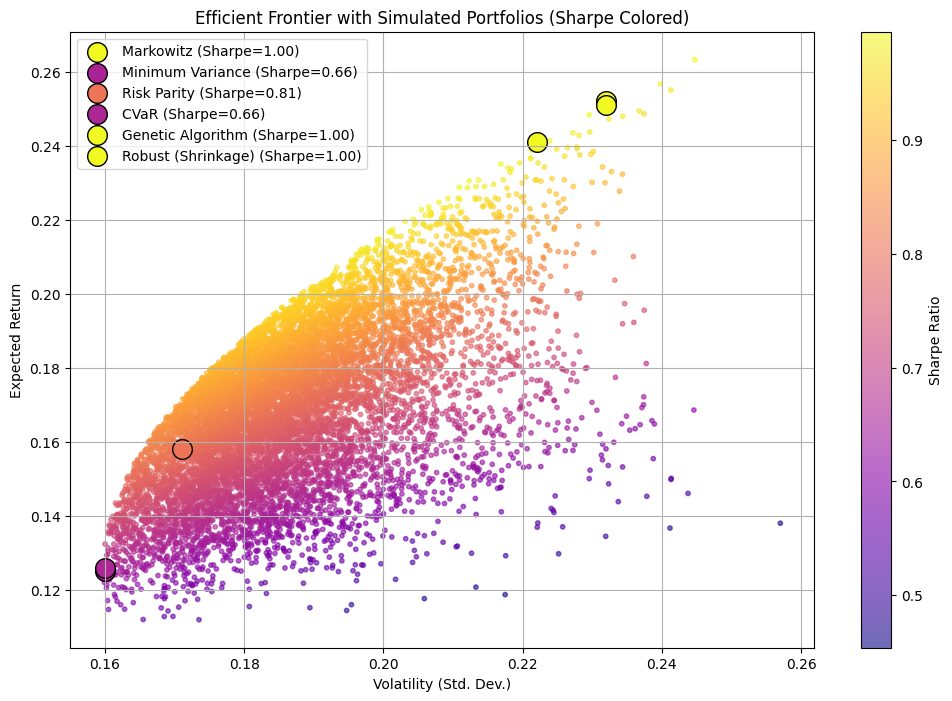

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# -----------------------------
# Download Data
# -----------------------------
tickers = ["AAPL", "JNJ", "JPM", "XOM", "PG"]
start_date = "2016-01-01"
end_date = "2023-12-31"

data = yf.download(tickers, start=start_date, end=end_date)["Close"]
returns = data.pct_change().dropna()

mean_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252
rf_rate = 0.02  # risk-free rate

# -----------------------------
# Monte Carlo Simulation of Portfolios
# -----------------------------
n_portfolios = 10000
results = np.zeros((3, n_portfolios))
weights_record = []

for i in range(n_portfolios):
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights)
    weights_record.append(weights)

    port_return = np.dot(weights, mean_returns)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe = (port_return - rf_rate) / port_vol

    results[0, i] = port_return
    results[1, i] = port_vol
    results[2, i] = sharpe

# Convert results into DataFrame
results_df = pd.DataFrame(results.T, columns=["Return", "Volatility", "Sharpe"])

# -----------------------------
# Given Portfolio Results
# -----------------------------
given_results = {
    "Markowitz": (0.232, 0.252),
   # "Black-Litterman": (0.195, 0.183),
    "Minimum Variance": (0.160, 0.125),
    "Risk Parity": (0.171, 0.158),
    "CVaR": (0.160, 0.126),
    "Genetic Algorithm": (0.222, 0.241),
    "Robust (Shrinkage)": (0.232, 0.251)
}
given_sharpes = {m: (ret - rf_rate) / vol for m, (vol, ret) in given_results.items()}

# -----------------------------
# Find Max Sharpe Portfolio
# -----------------------------
max_sharpe_idx = results_df["Sharpe"].idxmax()
max_sharpe_port = results_df.loc[max_sharpe_idx]

# -----------------------------
# Plot Efficient Frontier + Portfolios
# -----------------------------
plt.figure(figsize=(12, 8))

# All random portfolios (small scatter)
sc = plt.scatter(results_df["Volatility"], results_df["Return"],
                 c=results_df["Sharpe"], cmap="plasma", s=10, alpha=0.6)

plt.colorbar(sc, label="Sharpe Ratio")

# Given portfolios (big scatter points)
for method, (vol, ret) in given_results.items():
    plt.scatter(vol, ret, marker='o', s=200, edgecolors='black',
                c=[given_sharpes[method]], cmap="plasma", vmin=results_df["Sharpe"].min(),
                vmax=results_df["Sharpe"].max(),
                label=f"{method} (Sharpe={given_sharpes[method]:.2f})")


plt.xlabel("Volatility (Std. Dev.)")
plt.ylabel("Expected Return")
plt.title("Efficient Frontier with Simulated Portfolios (Sharpe Colored)")
plt.legend()
plt.grid(True)
plt.show()
